# Pipeline ETL — Dane energetyczne z ENTSO-E

Pobiera dane z [ENTSO-E Transparency Platform](https://transparency.entsoe.eu/) i zapisuje jako CSV.

Wymagania: klucz API w `.env` (`ENTSOE_API_KEY`). Plik wyjściowy: `datasets/energy_{KRAJ}_{OD}_{DO}.csv`

## 1. Konfiguracja

Dostępne kody krajów:

| Kod | Kraj | Kod | Kraj | Kod | Kraj |
|-----|------|-----|------|-----|------|
| AT | Austria | FR | Francja | NL | Holandia |
| BE | Belgia | DE | Niemcy | NO | Norwegia |
| BG | Bułgaria | GR | Grecja | PL | Polska |
| HR | Chorwacja | HU | Węgry | PT | Portugalia |
| CZ | Czechy | IE | Irlandia | RO | Rumunia |
| DK | Dania | IT | Włochy | RS | Serbia |
| EE | Estonia | LV | Łotwa | SK | Słowacja |
| FI | Finlandia | LT | Litwa | SI | Słowenia |
| ES | Hiszpania | LU | Luksemburg | SE | Szwecja |
| CH | Szwajcaria | GB | Wlk. Brytania | | |

In [1]:
COUNTRY_CODE = "PL"
START_DATE   = "2022-01-01"
END_DATE     = "2024-12-31"

## 2. Inicjalizacja

In [2]:
import os
import time
import warnings

import pandas as pd
from dotenv import load_dotenv
from entsoe import EntsoePandasClient

warnings.filterwarnings("ignore")

# ── Mapowanie krajów na strefy czasowe ──
COUNTRY_TIMEZONES = {
    "AT": "Europe/Vienna",    "BE": "Europe/Brussels",  "BG": "Europe/Sofia",
    "HR": "Europe/Zagreb",    "CZ": "Europe/Prague",    "DK": "Europe/Copenhagen",
    "EE": "Europe/Tallinn",   "FI": "Europe/Helsinki",  "FR": "Europe/Paris",
    "DE": "Europe/Berlin",    "GR": "Europe/Athens",    "HU": "Europe/Budapest",
    "IE": "Europe/Dublin",    "IT": "Europe/Rome",      "LV": "Europe/Riga",
    "LT": "Europe/Vilnius",   "LU": "Europe/Luxembourg","NL": "Europe/Amsterdam",
    "NO": "Europe/Oslo",      "PL": "Europe/Warsaw",    "PT": "Europe/Lisbon",
    "RO": "Europe/Bucharest", "RS": "Europe/Belgrade",  "SK": "Europe/Bratislava",
    "SI": "Europe/Ljubljana", "ES": "Europe/Madrid",    "SE": "Europe/Stockholm",
    "CH": "Europe/Zurich",    "GB": "Europe/London",
}

if COUNTRY_CODE not in COUNTRY_TIMEZONES:
    raise ValueError(f"Nieznany kod kraju: {COUNTRY_CODE}. Dostępne: {', '.join(sorted(COUNTRY_TIMEZONES))}")

TIMEZONE = COUNTRY_TIMEZONES[COUNTRY_CODE]
OUTPUT_PATH = f"datasets/energy_{COUNTRY_CODE}_{START_DATE}_{END_DATE}.csv"

print(f"Kraj:            {COUNTRY_CODE}")
print(f"Strefa czasowa:  {TIMEZONE} (automatycznie)")
print(f"Okres:           {START_DATE} → {END_DATE}")
print(f"Plik wyjściowy:  {OUTPUT_PATH}")

Kraj:            PL
Strefa czasowa:  Europe/Warsaw (automatycznie)
Okres:           2022-01-01 → 2024-12-31
Plik wyjściowy:  datasets/energy_PL_2022-01-01_2024-12-31.csv


In [3]:
load_dotenv()
API_KEY = os.getenv("ENTSOE_API_KEY")

if not API_KEY:
    raise ValueError("Brak klucza API! Dodaj ENTSOE_API_KEY do pliku .env")

client = EntsoePandasClient(api_key=API_KEY)

start = pd.Timestamp(START_DATE, tz=TIMEZONE)
end   = pd.Timestamp(END_DATE, tz=TIMEZONE) + pd.Timedelta(days=1)

print(f"Klient API gotowy.")
print(f"Zakres zapytań: {start} → {end}")

Klient API gotowy.
Zakres zapytań: 2022-01-01 00:00:00+01:00 → 2025-01-01 00:00:00+01:00


## 3. Funkcja pomocnicza — pobieranie danych w kawałkach

API ENTSO-E ogranicza ilość danych w jednym zapytaniu (maks. ~1 rok).  
Poniższa funkcja automatycznie dzieli zapytanie na mniejsze fragmenty i łączy wyniki.

In [4]:
def fetch_in_chunks(query_func, country_code, start, end, chunk_months=6, **kwargs):
    """
    Pobiera dane z API ENTSO-E w kawałkach po `chunk_months` miesięcy.
    Obsługuje limity API i automatycznie ponawia próby w razie błędów.
    """
    chunks = []
    current = start

    while current < end:
        chunk_end = min(current + pd.DateOffset(months=chunk_months), end)
        print(f"  Pobieram: {current.date()} → {chunk_end.date()} ... ", end="")

        for attempt in range(3):
            try:
                result = query_func(country_code, start=current, end=chunk_end, **kwargs)
                chunks.append(result)
                print(f"OK ({len(result)} wierszy)")
                break
            except Exception as e:
                if attempt < 2:
                    wait = 10 * (attempt + 1)
                    print(f"Błąd, ponawiam za {wait}s...")
                    time.sleep(wait)
                else:
                    print(f"BŁĄD: {e}")
                    raise

        current = chunk_end
        time.sleep(1)

    combined = pd.concat(chunks)
    combined = combined[~combined.index.duplicated(keep="first")]
    return combined.sort_index()


def safe_fetch(query_func, country_code, start, end, label, **kwargs):
    """Wrapper z obsługą błędów — jeśli dany typ danych nie jest dostępny, zwraca None."""
    print(f"\n{'='*60}")
    print(f"Pobieranie: {label}")
    print(f"{'='*60}")
    try:
        return fetch_in_chunks(query_func, country_code, start, end, **kwargs)
    except Exception as e:
        print(f"  ⚠ Nie udało się pobrać danych: {e}")
        print(f"  → Te dane mogą nie być dostępne dla kraju {country_code}")
        return None

## 4. Pobieranie danych

Pobieramy 4 typy danych z ENTSO-E:
- **Produkcja energii** (generation) — z podziałem na źródła
- **Prognozy** wiatru i słońca (forecasts)
- **Obciążenie sieci** — rzeczywiste i prognozowane (load)
- **Ceny energii** — rynek dnia następnego (prices)

Nie każdy kraj udostępnia wszystkie typy danych — brakujące zostaną oznaczone jako NaN.

In [5]:
generation_raw = safe_fetch(client.query_generation, COUNTRY_CODE, start, end,
                            "Produkcja energii (generation)")

forecast_raw = safe_fetch(client.query_wind_and_solar_forecast, COUNTRY_CODE, start, end,
                          "Prognozy wiatr/słońce (forecast)")

load_actual_raw = safe_fetch(client.query_load, COUNTRY_CODE, start, end,
                             "Obciążenie rzeczywiste (load actual)")

load_forecast_raw = safe_fetch(client.query_load_forecast, COUNTRY_CODE, start, end,
                               "Prognoza obciążenia (load forecast)")

price_da_raw = safe_fetch(client.query_day_ahead_prices, COUNTRY_CODE, start, end,
                          "Ceny day-ahead (prices)")

print(f"\n{'='*60}")
print("Pobieranie zakończone.")


Pobieranie: Produkcja energii (generation)
  Pobieram: 2022-01-01 → 2022-07-01 ... OK (4343 wierszy)
  Pobieram: 2022-07-01 → 2023-01-01 ... OK (4417 wierszy)
  Pobieram: 2023-01-01 → 2023-07-01 ... OK (4343 wierszy)
  Pobieram: 2023-07-01 → 2024-01-01 ... OK (4417 wierszy)
  Pobieram: 2024-01-01 → 2024-07-01 ... OK (5657 wierszy)
  Pobieram: 2024-07-01 → 2025-01-01 ... OK (17668 wierszy)

Pobieranie: Prognozy wiatr/słońce (forecast)
  Pobieram: 2022-01-01 → 2022-07-01 ... OK (4343 wierszy)
  Pobieram: 2022-07-01 → 2023-01-01 ... OK (4417 wierszy)
  Pobieram: 2023-01-01 → 2023-07-01 ... OK (4343 wierszy)
  Pobieram: 2023-07-01 → 2024-01-01 ... OK (4417 wierszy)
  Pobieram: 2024-01-01 → 2024-07-01 ... OK (5657 wierszy)
  Pobieram: 2024-07-01 → 2025-01-01 ... OK (17668 wierszy)

Pobieranie: Obciążenie rzeczywiste (load actual)
  Pobieram: 2022-01-01 → 2022-07-01 ... OK (4343 wierszy)
  Pobieram: 2022-07-01 → 2023-01-01 ... OK (4417 wierszy)
  Pobieram: 2023-01-01 → 2023-07-01 ... OK (43

## 5. Mapowanie i standaryzacja kolumn

API ENTSO-E zwraca dane z różnymi nazwami kolumn (zależy od kraju).  
Poniższy kod mapuje je na ustandaryzowany format.

In [6]:
def flatten_columns(raw_df):
    """Spłaszcza MultiIndex kolumn do pojedynczych nazw."""
    if raw_df is None:
        return None
    if isinstance(raw_df.columns, pd.MultiIndex):
        raw_df.columns = [f"{a} - {b}" if b else a for a, b in raw_df.columns]
    return raw_df


def map_generation_columns(raw_df):
    """Mapuje kolumny generacji z API na standardowe nazwy."""
    if raw_df is None:
        return pd.DataFrame()

    raw_df = flatten_columns(raw_df)

    GENERATION_MAP = {
        "Biomass":                            "generation biomass",
        "Fossil Brown coal/Lignite":           "generation fossil brown coal/lignite",
        "Fossil Coal-derived gas":             "generation fossil coal-derived gas",
        "Fossil Gas":                          "generation fossil gas",
        "Fossil Hard coal":                    "generation fossil hard coal",
        "Fossil Oil":                          "generation fossil oil",
        "Fossil Oil shale":                    "generation fossil oil shale",
        "Fossil Peat":                         "generation fossil peat",
        "Geothermal":                          "generation geothermal",
        "Hydro Pumped Storage":                "generation hydro pumped storage aggregated",
        "Hydro Pumped Storage Consumption":    "generation hydro pumped storage consumption",
        "Hydro Run-of-river and poundage":     "generation hydro run-of-river and poundage",
        "Hydro Water Reservoir":               "generation hydro water reservoir",
        "Marine":                              "generation marine",
        "Nuclear":                             "generation nuclear",
        "Other":                               "generation other",
        "Other renewable":                     "generation other renewable",
        "Solar":                               "generation solar",
        "Waste":                               "generation waste",
        "Wind Offshore":                       "generation wind offshore",
        "Wind Onshore":                        "generation wind onshore",
    }

    result = pd.DataFrame(index=raw_df.index)
    for api_name, csv_name in GENERATION_MAP.items():
        matched = [c for c in raw_df.columns if api_name in c and "Consumption" not in c]
        if api_name == "Hydro Pumped Storage Consumption":
            matched = [c for c in raw_df.columns if "Hydro Pumped Storage" in c and "Consumption" in c]
        result[csv_name] = raw_df[matched[0]] if matched else float("nan")

    return result


def map_forecast_columns(raw_df):
    """Mapuje kolumny prognoz."""
    if raw_df is None:
        return pd.DataFrame()

    raw_df = flatten_columns(raw_df)
    FORECAST_MAP = {
        "Solar":         "forecast solar day ahead",
        "Wind Offshore": "forecast wind offshore eday ahead",
        "Wind Onshore":  "forecast wind onshore day ahead",
    }

    result = pd.DataFrame(index=raw_df.index)
    for api_name, csv_name in FORECAST_MAP.items():
        matched = [c for c in raw_df.columns if api_name in str(c)]
        result[csv_name] = raw_df[matched[0]] if matched else float("nan")

    return result


def extract_series(raw, name):
    """Wyciąga pojedynczą kolumnę z DataFrame lub Series."""
    if raw is None:
        return pd.Series(dtype=float, name=name)
    if isinstance(raw, pd.DataFrame):
        s = raw.iloc[:, 0]
    else:
        s = raw
    s.name = name
    return s


# ── Mapowanie ──
generation = map_generation_columns(generation_raw)
forecast   = map_forecast_columns(forecast_raw)

load_actual   = extract_series(load_actual_raw, "total load actual")
load_forecast = extract_series(load_forecast_raw, "total load forecast")
price_da      = extract_series(price_da_raw, "price day ahead")

print(f"Generacja:  {generation.shape}")
print(f"Prognozy:   {forecast.shape}")
print(f"Load:       {len(load_actual)} + {len(load_forecast)} wierszy")
print(f"Ceny:       {len(price_da)} wierszy")

Generacja:  (40845, 21)
Prognozy:   (40845, 3)
Load:       40845 + 40845 wierszy
Ceny:       26305 wierszy


## 6. Łączenie danych i walidacja

In [7]:
parts = [generation, forecast]

load_df = pd.DataFrame(index=load_actual.index if len(load_actual) > 0 else load_forecast.index)
if len(load_actual) > 0:
    load_df["total load actual"] = load_actual
if len(load_forecast) > 0:
    load_df["total load forecast"] = load_forecast.reindex(load_df.index)
parts.append(load_df)

if len(price_da) > 0:
    price_df = price_da.to_frame()
    parts.append(price_df)

valid_parts = [p for p in parts if len(p) > 0]
if not valid_parts:
    raise RuntimeError("Nie udało się pobrać żadnych danych!")

df = valid_parts[0]
for part in valid_parts[1:]:
    df = df.join(part, how="outer")

df.index.name = "time"
df = df.sort_index()

print(f"Kształt finalnego DataFrame:  {df.shape}")
print(f"Zakres dat:                   {df.index.min()} → {df.index.max()}")
print(f"Kolumny ({df.shape[1]}):")
for i, col in enumerate(df.columns, 1):
    na_count = df[col].isna().sum()
    na_pct = na_count / len(df) * 100
    status = "" if na_pct == 0 else f"  ({na_count} braków = {na_pct:.1f}%)"
    if na_pct == 100:
        status = "  (brak danych)"
    print(f"  {i:2d}. {col}{status}")

Kształt finalnego DataFrame:  (40846, 27)
Zakres dat:                   2022-01-01 00:00:00+01:00 → 2025-01-01 00:00:00+01:00
Kolumny (27):
   1. generation biomass  (1 braków = 0.0%)
   2. generation fossil brown coal/lignite  (1 braków = 0.0%)
   3. generation fossil coal-derived gas  (1 braków = 0.0%)
   4. generation fossil gas  (1 braków = 0.0%)
   5. generation fossil hard coal  (1 braków = 0.0%)
   6. generation fossil oil  (1 braków = 0.0%)
   7. generation fossil oil shale  (brak danych)
   8. generation fossil peat  (brak danych)
   9. generation geothermal  (brak danych)
  10. generation hydro pumped storage aggregated  (1 braków = 0.0%)
  11. generation hydro pumped storage consumption  (brak danych)
  12. generation hydro run-of-river and poundage  (1 braków = 0.0%)
  13. generation hydro water reservoir  (1 braków = 0.0%)
  14. generation marine  (brak danych)
  15. generation nuclear  (brak danych)
  16. generation other  (21546 braków = 52.7%)
  17. generation other ren

In [8]:
df.head()

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load actual,total load forecast,price day ahead
time,,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00+01:00,223.07,2514.45,64.53,994.46,5686.18,279.59,NaN,NaN,NaN,3.01,...,0.0,NaN,NaN,4255.65,0.0,NaN,4006.30,14910.84,15450.0,59.03
2022-01-01 01:00:00+01:00,221.05,2422.32,64.48,995.78,5684.95,279.59,NaN,NaN,NaN,0.00,...,0.0,NaN,NaN,4243.99,0.0,NaN,3905.07,14438.25,14750.0,49.37
2022-01-01 02:00:00+01:00,221.36,2466.18,63.68,1003.19,5682.59,277.15,NaN,NaN,NaN,0.00,...,0.0,NaN,NaN,4071.18,0.0,NaN,3870.41,13934.85,14100.0,43.22
2022-01-01 03:00:00+01:00,222.97,2560.41,65.18,995.51,5703.75,275.64,NaN,NaN,NaN,0.00,...,0.0,NaN,NaN,3996.89,0.0,NaN,3864.14,13579.01,13700.0,45.46
2022-01-01 04:00:00+01:00,225.48,2419.55,64.69,995.75,5621.37,275.93,NaN,NaN,NaN,0.00,...,0.0,NaN,NaN,4104.83,0.0,NaN,3813.63,13396.76,13450.0,37.67


## 7. Zapis do pliku CSV

In [9]:
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
df.to_csv(OUTPUT_PATH)

size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f"Zapisano: {OUTPUT_PATH}")
print(f"Rozmiar:  {size_mb:.1f} MB")
print(f"Wiersze:  {len(df):,}")
print(f"Kolumny:  {df.shape[1]}")

Zapisano: datasets/energy_PL_2022-01-01_2024-12-31.csv
Rozmiar:  6.1 MB
Wiersze:  40,846
Kolumny:  27


## 8. Podgląd pobranych danych

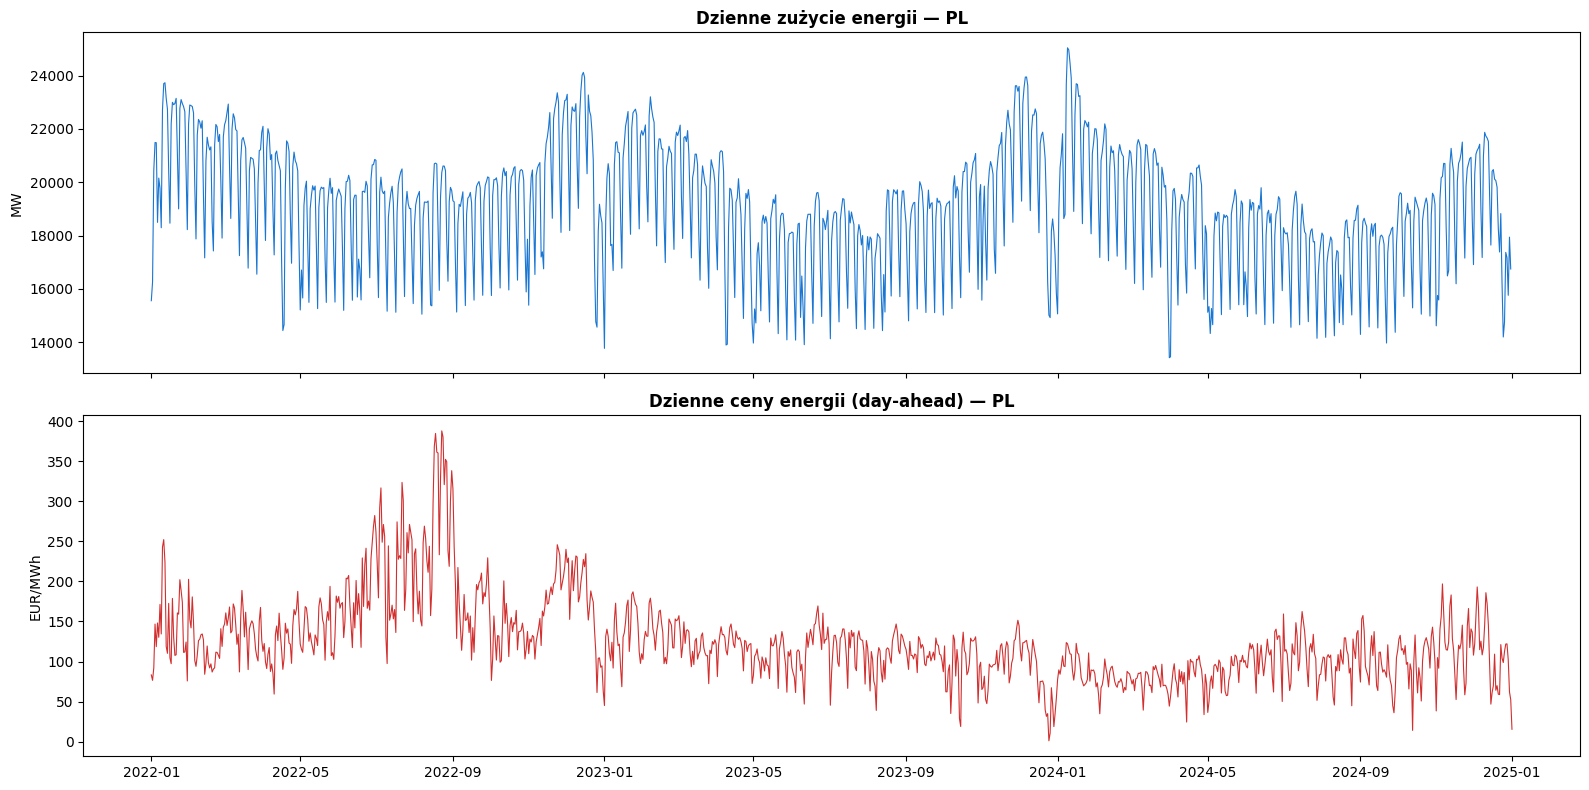


Gotowe! Plik zapisany jako: datasets/energy_PL_2022-01-01_2024-12-31.csv


In [10]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include="number").columns
has_load = "total load actual" in numeric_cols
has_price = "price day ahead" in numeric_cols
n_plots = int(has_load) + int(has_price)

if n_plots > 0:
    fig, axes = plt.subplots(n_plots, 1, figsize=(16, 4 * n_plots), sharex=True)
    if n_plots == 1:
        axes = [axes]

    plot_idx = 0
    if has_load:
        daily = df["total load actual"].resample("D").mean()
        axes[plot_idx].plot(daily, linewidth=0.8, color="#1976D2")
        axes[plot_idx].set_title(f"Dzienne zużycie energii — {COUNTRY_CODE}", fontweight="bold")
        axes[plot_idx].set_ylabel("MW")
        plot_idx += 1

    if has_price:
        daily_p = df["price day ahead"].resample("D").mean()
        axes[plot_idx].plot(daily_p, linewidth=0.8, color="#D32F2F")
        axes[plot_idx].set_title(f"Dzienne ceny energii (day-ahead) — {COUNTRY_CODE}", fontweight="bold")
        axes[plot_idx].set_ylabel("EUR/MWh")

    plt.tight_layout()
    plt.show()
else:
    print("Brak danych load/price do wizualizacji.")

print(f"\nGotowe! Plik zapisany jako: {OUTPUT_PATH}")